In [2]:
import pandas as pd
import numpy as np

C:\Users\caden\AppData\Local\Temp\ipykernel_35196\2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Read in Dataset

In [3]:
df = pd.read_csv('Data/Bay_AI.csv')
df

,fid,GEOID,COUNTYFP,NAMELSAD,median_hh_,median_h_1,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,CENSUS_PLA,...,acs_2024_tracts_berkeley_oakland_sf_density_median_income,acs_2024_tracts_berkeley_oakland_sf_density_median_home_value,acs_2024_tracts_berkeley_oakland_sf_density_housing_units_total,acs_2024_tracts_berkeley_oakland_sf_density_owner_occupied,acs_2024_tracts_berkeley_oakland_sf_density_renter_occupied,acs_2024_tracts_berkeley_oakland_sf_density_homeownership_rate,acs_2024_tracts_berkeley_oakland_sf_density_area_sq_miles,acs_2024_tracts_berkeley_oakland_sf_density_pop_density,weight_supply_sum,Accessibility_Index
0,516,6001423300,1,Census Tract 4233,83450.0,33008.0,1013,Berkeley,Alameda County,Berkeley,...,101571.0,1101900.0,1476.0,829.0,647.0,0.561653,0.280259,12927.323847,2.354986e+08,6.500098e+04
1,471,6001424002,1,Census Tract 4240.02,103393.0,36279.0,1013,Berkeley,Alameda County,Berkeley,...,105813.0,1233500.0,1050.0,553.0,497.0,0.526667,0.128952,19573.106618,2.236313e+08,8.860192e+04
2,469,6001423000,1,Census Tract 4230,86917.0,20998.0,1013,Berkeley,Alameda County,Berkeley,...,110536.0,1353400.0,2023.0,842.0,1181.0,0.416214,0.281880,15886.203445,3.683170e+08,8.225032e+04
3,541,6001423400,1,Census Tract 4234,107455.0,27066.0,1013,Berkeley,Alameda County,Berkeley,...,145789.0,1362400.0,1974.0,965.0,1009.0,0.488855,0.292162,17859.957608,2.601037e+08,4.984739e+04
4,372,6001424001,1,Census Tract 4240.01,87500.0,33040.0,1013,Berkeley,Alameda County,Berkeley,...,82125.0,1197500.0,1535.0,452.0,1083.0,0.294463,0.196049,20403.077463,3.058869e+08,7.647171e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,288,6075980300,75,Census Tract 9803,NaN,NaN,38001,San Francisco,San Francisco County,San Francisco,...,107188.0,NaN,46.0,0.0,46.0,0.000000,1.713716,33.844580,1.081020e+09,1.863827e+07
492,1125,6075047904,75,Census Tract 479.04,84880.0,30787.0,38001,San Francisco,San Francisco County,San Francisco,...,105577.0,1631000.0,1380.0,695.0,685.0,0.503623,0.284483,10816.112052,2.393140e+08,7.777511e+04
493,291,6075980200,75,Census Tract 9802,NaN,NaN,38001,San Francisco,San Francisco County,San Francisco,...,NaN,NaN,0.0,0.0,0.0,NaN,0.384468,416.159016,1.733443e+08,1.083402e+06
494,1336,6075042800,75,Census Tract 428,250001.0,NaN,38001,San Francisco,San Francisco County,San Francisco,...,250001.0,2000001.0,959.0,734.0,225.0,0.765381,0.225254,10969.820071,2.576146e+08,1.042552e+05


## Clean up dataset

In [4]:
# Check number of rows that have nulls
print(df.iloc[:,-1].isnull().sum())

26


In [5]:
# Drop rows where AI is null
last_col = df.columns[-1]
df = df.dropna(subset=[last_col])

In [6]:
df

,fid,GEOID,COUNTYFP,NAMELSAD,median_hh_,median_h_1,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,CENSUS_PLA,...,acs_2024_tracts_berkeley_oakland_sf_density_median_income,acs_2024_tracts_berkeley_oakland_sf_density_median_home_value,acs_2024_tracts_berkeley_oakland_sf_density_housing_units_total,acs_2024_tracts_berkeley_oakland_sf_density_owner_occupied,acs_2024_tracts_berkeley_oakland_sf_density_renter_occupied,acs_2024_tracts_berkeley_oakland_sf_density_homeownership_rate,acs_2024_tracts_berkeley_oakland_sf_density_area_sq_miles,acs_2024_tracts_berkeley_oakland_sf_density_pop_density,weight_supply_sum,Accessibility_Index
0,516,6001423300,1,Census Tract 4233,83450.0,33008.0,1013,Berkeley,Alameda County,Berkeley,...,101571.0,1101900.0,1476.0,829.0,647.0,0.561653,0.280259,12927.323847,2.354986e+08,6.500098e+04
1,471,6001424002,1,Census Tract 4240.02,103393.0,36279.0,1013,Berkeley,Alameda County,Berkeley,...,105813.0,1233500.0,1050.0,553.0,497.0,0.526667,0.128952,19573.106618,2.236313e+08,8.860192e+04
2,469,6001423000,1,Census Tract 4230,86917.0,20998.0,1013,Berkeley,Alameda County,Berkeley,...,110536.0,1353400.0,2023.0,842.0,1181.0,0.416214,0.281880,15886.203445,3.683170e+08,8.225032e+04
3,541,6001423400,1,Census Tract 4234,107455.0,27066.0,1013,Berkeley,Alameda County,Berkeley,...,145789.0,1362400.0,1974.0,965.0,1009.0,0.488855,0.292162,17859.957608,2.601037e+08,4.984739e+04
4,372,6001424001,1,Census Tract 4240.01,87500.0,33040.0,1013,Berkeley,Alameda County,Berkeley,...,82125.0,1197500.0,1535.0,452.0,1083.0,0.294463,0.196049,20403.077463,3.058869e+08,7.647171e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,288,6075980300,75,Census Tract 9803,NaN,NaN,38001,San Francisco,San Francisco County,San Francisco,...,107188.0,NaN,46.0,0.0,46.0,0.000000,1.713716,33.844580,1.081020e+09,1.863827e+07
492,1125,6075047904,75,Census Tract 479.04,84880.0,30787.0,38001,San Francisco,San Francisco County,San Francisco,...,105577.0,1631000.0,1380.0,695.0,685.0,0.503623,0.284483,10816.112052,2.393140e+08,7.777511e+04
493,291,6075980200,75,Census Tract 9802,NaN,NaN,38001,San Francisco,San Francisco County,San Francisco,...,NaN,NaN,0.0,0.0,0.0,NaN,0.384468,416.159016,1.733443e+08,1.083402e+06
494,1336,6075042800,75,Census Tract 428,250001.0,NaN,38001,San Francisco,San Francisco County,San Francisco,...,250001.0,2000001.0,959.0,734.0,225.0,0.765381,0.225254,10969.820071,2.576146e+08,1.042552e+05


In [7]:
df.isnull().sum()


fid                                                                 0
GEOID                                                               0
COUNTYFP                                                            0
NAMELSAD                                                            0
median_hh_                                                         15
median_h_1                                                         28
CDTFA_COPR                                                          0
CDTFA_CITY                                                          0
CDTFA_COUN                                                          0
CENSUS_PLA                                                          0
CENSUS_GEO                                                          0
CENSUS_P_1                                                          0
GNIS_PLACE                                                          0
GNIS_ID                                                             0
acs_2024_tracts_berk

In [8]:
# Fill in missing values (median_hh_, median_h_1)
median_hh_column = df['median_hh_'].median()
median_h_1_column = df['median_h_1'].median()

df = df.fillna({
    'median_hh_': median_hh_column,
    'median_h_1': median_h_1_column
})

In [9]:
df.isnull().sum()

fid                                                                 0
GEOID                                                               0
COUNTYFP                                                            0
NAMELSAD                                                            0
median_hh_                                                          0
median_h_1                                                          0
CDTFA_COPR                                                          0
CDTFA_CITY                                                          0
CDTFA_COUN                                                          0
CENSUS_PLA                                                          0
CENSUS_GEO                                                          0
CENSUS_P_1                                                          0
GNIS_PLACE                                                          0
GNIS_ID                                                             0
acs_2024_tracts_berk

## Training the model

In [10]:
df.columns

Index(['fid', 'GEOID', 'COUNTYFP', 'NAMELSAD', 'median_hh_', 'median_h_1',
       'CDTFA_COPR', 'CDTFA_CITY', 'CDTFA_COUN', 'CENSUS_PLA', 'CENSUS_GEO',
       'CENSUS_P_1', 'GNIS_PLACE', 'GNIS_ID',
       'acs_2024_tracts_berkeley_oakland_sf_density_city',
       'acs_2024_tracts_berkeley_oakland_sf_density_NAME',
       'acs_2024_tracts_berkeley_oakland_sf_density_year',
       'acs_2024_tracts_berkeley_oakland_sf_density_total_pop',
       'acs_2024_tracts_berkeley_oakland_sf_density_white_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_black_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_asian_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_hispanic',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_white_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_black_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_asian_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_hispanic',
       'acs_2024_tracts_berkeley_oakland_

In [11]:
# Get features and target variables 
features = ['median_hh_',
                'acs_2024_tracts_berkeley_oakland_sf_density_total_pop',
                'acs_2024_tracts_berkeley_oakland_sf_density_pct_white_nh',
                'acs_2024_tracts_berkeley_oakland_sf_density_pct_black_nh',
                'acs_2024_tracts_berkeley_oakland_sf_density_pct_asian_nh',
                'acs_2024_tracts_berkeley_oakland_sf_density_pct_hispanic',
                'acs_2024_tracts_berkeley_oakland_sf_density_pct_poc',
                'acs_2024_tracts_berkeley_oakland_sf_density_owner_occupied',
                'acs_2024_tracts_berkeley_oakland_sf_density_homeownership_rate',
                'acs_2024_tracts_berkeley_oakland_sf_density_pop_density',
                'acs_2024_tracts_berkeley_oakland_sf_density_housing_units_total',
                'acs_2024_tracts_berkeley_oakland_sf_density_area_sq_miles']
X = df[features].fillna(0).values
y = df.iloc[:, -1].values


In [12]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
lr_pred = lr.predict(X)

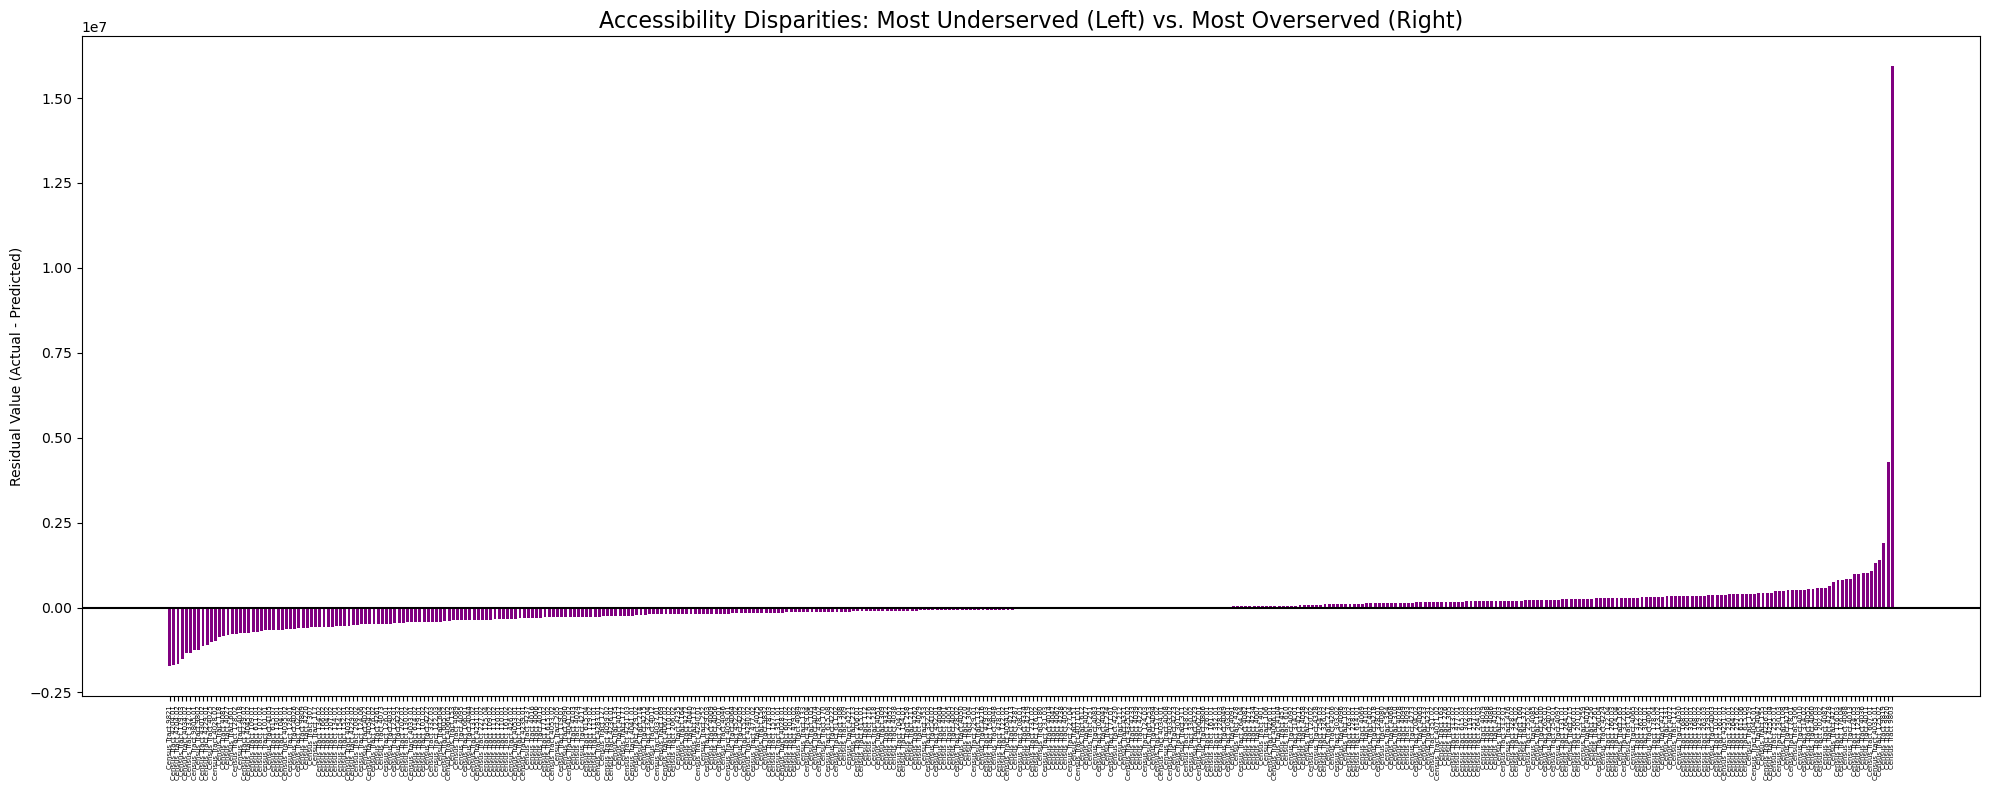

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the results dataframe
# We use .copy() to avoid 'SettingWithCopyWarning'
results_df = df[['GEOID', 'NAMELSAD']].copy()

# 2. Add the actual, predicted, and residual columns
results_df['Actual'] = y
results_df['Predicted'] = lr_pred
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

# 3. SORT the data (This is the secret to a readable chart!)
# Sorting puts the most underserved tracts on the left
results_df = results_df.sort_values(by='Residual')

# 4. Plot with extra padding
plt.figure(figsize=(20, 8))
plt.bar(results_df['NAMELSAD'], results_df['Residual'], color='purple', width=0.7)

plt.axhline(0, color='black', lw=1.5)
plt.xticks(rotation=90, fontsize=5) 

plt.title("Accessibility Disparities: Most Underserved (Left) vs. Most Overserved (Right)", fontsize=16)
plt.ylabel("Residual Value (Actual - Predicted)")
plt.tight_layout()

plt.show()